---
title: "Sentiment Analysis"
format:
  html:
    embed-resources: true
    code-fold: true
    toc: true
---

## Overview

The goal of this tab is to display the sentiment analysis procedure followed in the project. In this method, we have used the pretrained model sentimentdl_use_twitter from John Snow labs, as it has been built to leverage spark NLP while being trained on Twitter data.

![](images/sentiment.png){fig-align="center" width=50% }

### Assumptions

In this project we are assuming that the slang utilized in Reddit and Twitter is pretty similar, especially on political comments. Thus, we will be relying on this model to classify the sentiment of the Reddit posts, which is a crucial step in our labeling procedure.

## Process

1) Importing libraries and initializing spark session

In [ ]:
from pyspark.sql.functions import *
# from pyspark.sql import SparkSession
import sparknlp
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import UniversalSentenceEncoder, SentimentDLModel
from sparknlp.pretrained import PretrainedPipeline
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline


2) Reading in the data

In [ ]:
dataset_submissions = spark.read.parquet("azureml://datastores/workspaceblobstore/paths/cleandata/submissions_w_keywords_no_filter.parquet") \
  .withColumnRenamed("Roe v. Wade", "Roe_v_Wade").withColumnRenamed("selftext", "body")

dataset_comments = spark.read.parquet("azureml://datastores/workspaceblobstore/paths/cleandata/comments_w_keywords_no_filter.parquet") \
  .withColumnRenamed("Roe v. Wade", "Roe_v_Wade")

3) Setting up the sentiment analysis pipeline and fitting the model

In [ ]:
documentAssembler = DocumentAssembler()\
    .setInputCol("body")\
    .setOutputCol("document")
    
use = UniversalSentenceEncoder.pretrained(name="tfhub_use", lang="en")\
 .setInputCols(["document"])\
 .setOutputCol("sentence_embeddings")


sentimentdl = SentimentDLModel.pretrained(name="sentimentdl_use_twitter", lang="en")\
    .setInputCols(["sentence_embeddings"])\
    .setOutputCol("sentiment")

nlpPipeline = Pipeline(
    stages = [
        documentAssembler,
        use,
        sentimentdl
        ])


In [ ]:
result_submissions = nlpPipeline.fit(dataset_submissions).transform(dataset_submissions)
result_comments = nlpPipeline.fit(dataset_comments).transform(dataset_comments)

4) Extracting only the sentiment from the model and saving the data

In [ ]:
result_comments = result_comments.withColumn(
    "simple_sentiment",
    col("sentiment").getItem(0)["result"]
)

result_submissions = result_submissions.withColumn(
    "simple_sentiment",
    col("sentiment").getItem(0)["result"]
)

In [ ]:
result_submissions.write.mode("overwrite").parquet("azureml://datastores/workspaceblobstore/paths/cleandata/submissions_w_keywords_and_sentiment.parquet")
result_comments.write.mode("overwrite").parquet("azureml://datastores/workspaceblobstore/paths/cleandata/comments_w_keywords_and_sentiment.parquet")

## Data

Take a look at how the data looks after the sentiment analysis has been performed. Keep in mind that all the keyword columns added in the previous work are still present as we will use them along with the sentiment to label the data.

**Note:** This model outputs additional information not needed for our purposes, so in step 4 we have extracted the overall sentiment value of the post.

#### Submissions

In [8]:
result_submissions.show(5)

StatementMeta(, , , Waiting, , Waiting)

+------+--------------------+--------------------+-------------------+------------+--------------------+----+-----+--------------+--------------+------------+----------+------------+---------+--------+-----------+------+-------------+----------+---------------------+----------------+--------+---------------+------------+------------------+-----------+---------+-----------+--------+--------+---------------+-----------------------+-----------------+-------------+---------------+------------------------+---------------+-------------+-----------------+----------+--------------+--------+----------------+-------------+----------------+---------------+---------------+------------------+-----------------+------------+-----------------+-----+--------+-----------------+-------------+---------------+--------------+-------------+-------+-----------+-------------------+-------------------+---------------+--------------+----------+-----+----------------------+---------------------+----------------+-

##### Comments

In [23]:
result_comments.show(5)

StatementMeta(11387b7c-91c2-4dd1-a4f8-a460b59b7bdd, 48, 33, Finished, Available, Finished)

+-------+--------------+--------------------+-------------------+----+-----+-----------------+--------------+------------+----------+------------+---------+--------+-----------+------+-------------+----------+---------------------+----------------+--------+---------------+------------+------------------+-----------+---------+-----------+--------+--------+---------------+-----------------------+-----------------+-------------+---------------+------------------------+---------------+-------------+-----------------+----------+--------------+--------+----------------+-------------+----------------+---------------+---------------+------------------+-----------------+------------+-----------------+-----+--------+-----------------+-------------+---------------+--------------+-------------+-------+-----------+-------------------+-------------------+---------------+--------------+----------+-----+----------------------+---------------------+----------------+---------------+---------+-----------

## Positive and negative counts

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 82, 17, Finished, Available, Finished)

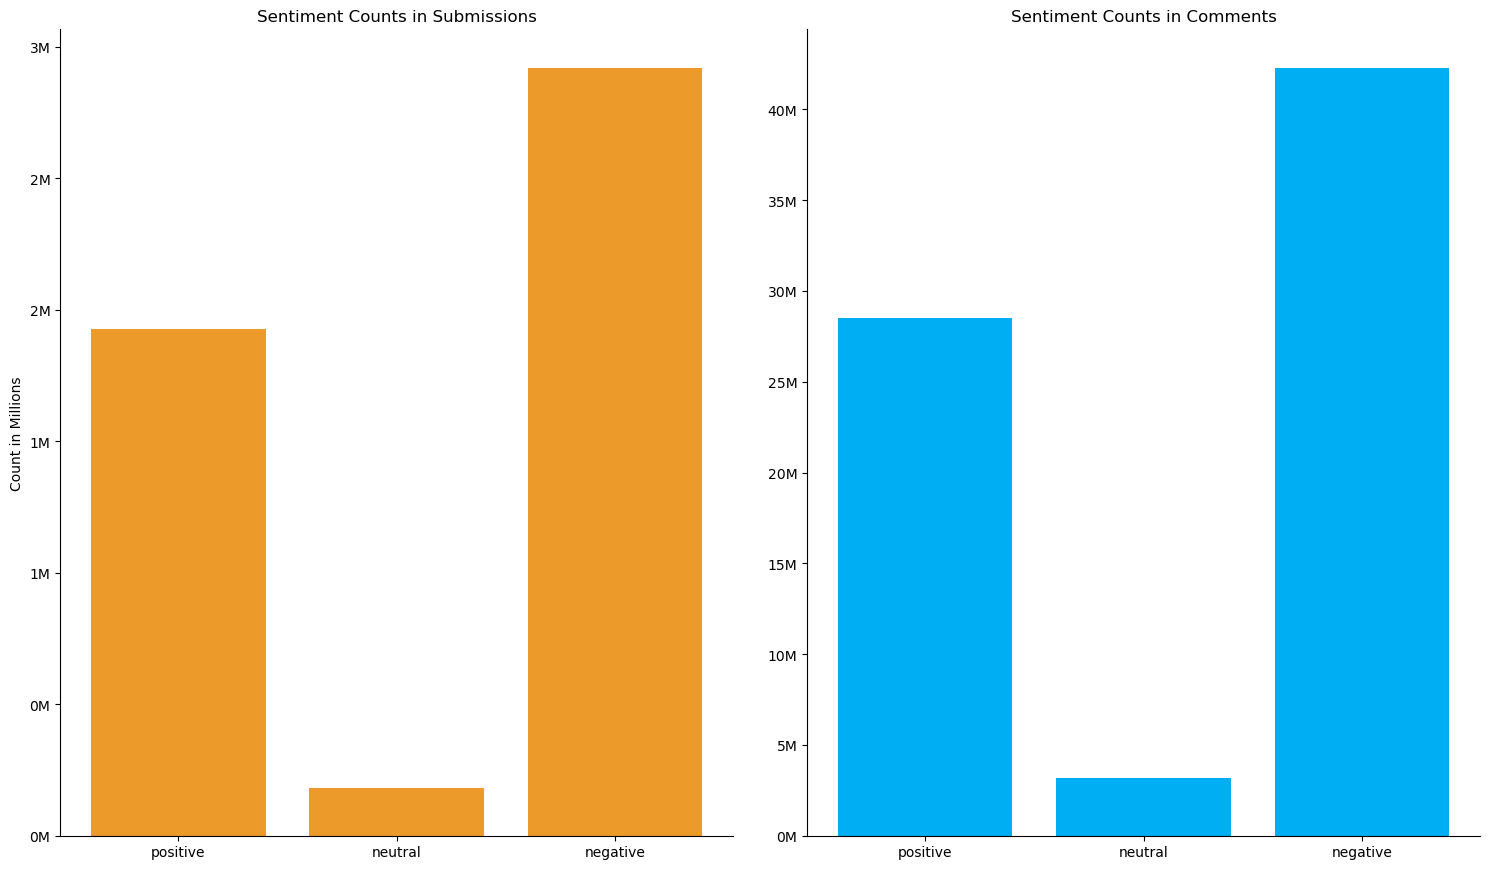

In [12]:
spark
import matplotlib.ticker as ticker
from azureml.core import Workspace, Datastore, Dataset
import matplotlib.pyplot as plt

subscription_id = 'My_ID'
resource_group = 'project-group-11'
workspace_name = 'project-group-11'

workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "workspaceblobstore")

dataset_submissions = spark.read.parquet("azureml://datastores/workspaceblobstore/paths/cleandata/submissions_w_keywords_and_sentiment.parquet")
dataset_comments = spark.read.parquet("azureml://datastores/workspaceblobstore/paths/cleandata/comments_w_keywords_and_sentiment.parquet")

sentiment_counts_submissions = dataset_submissions.groupBy("simple_sentiment").count()
sentiment_counts_comments = dataset_comments.groupBy("simple_sentiment").count()

pd_sentiment_counts_submissions = sentiment_counts_submissions.toPandas()
pd_sentiment_counts_comments = sentiment_counts_comments.toPandas()

# Create fig
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 9))

# Plot for submissions
axes[0].bar(pd_sentiment_counts_submissions['simple_sentiment'], pd_sentiment_counts_submissions['count'], color='#EC9A29', tick_label=pd_sentiment_counts_submissions['simple_sentiment'])
axes[0].set_title('Sentiment Counts in Submissions')
axes[0].set_xlabel(' ')
axes[0].set_ylabel('Count in Millions')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}M')
axes[0].yaxis.set_major_formatter(formatter)

# Plot for comments
axes[1].bar(pd_sentiment_counts_comments['simple_sentiment'], pd_sentiment_counts_comments['count'], color='#00AEF3', tick_label=pd_sentiment_counts_comments['simple_sentiment'])
axes[1].set_title('Sentiment Counts in Comments')
axes[1].set_xlabel(' ')
axes[1].set_ylabel(' ')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}M')
axes[1].yaxis.set_major_formatter(formatter)

# Show plot
plt.tight_layout()
plt.show()